In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import  accuracy_score , f1_score , precision_score , recall_score , log_loss , roc_auc_score , confusion_matrix
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer





<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام اول – بارگذاری مجموعه داده و تحلیل اولیه</p>


In [24]:
dataset = pd.read_csv("enhanced_anxiety_dataset.csv")

In [25]:
dataset

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,Female,Engineer,6.1,3.1,566,9,Yes,No,8,91,28,1,Yes,Yes,1,No,3,6.0
10996,50,Other,Teacher,6.6,3.6,64,17,Yes,No,7,95,17,3,No,No,2,No,7,3.0
10997,29,Male,Nurse,6.7,6.9,159,14,No,No,8,72,16,1,Yes,Yes,2,Yes,7,4.0
10998,53,Other,Artist,5.7,2.7,248,8,No,No,4,112,28,3,Yes,Yes,1,Yes,2,4.0


In [26]:
dataset["binary_anxiety"] = dataset["Anxiety Level (1-10)"].apply(lambda x: 1 if x >= 5 else 0)

dataset

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),binary_anxiety
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0,1
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0,0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0,0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0,0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,Female,Engineer,6.1,3.1,566,9,Yes,No,8,91,28,1,Yes,Yes,1,No,3,6.0,1
10996,50,Other,Teacher,6.6,3.6,64,17,Yes,No,7,95,17,3,No,No,2,No,7,3.0,0
10997,29,Male,Nurse,6.7,6.9,159,14,No,No,8,72,16,1,Yes,Yes,2,Yes,7,4.0,0
10998,53,Other,Artist,5.7,2.7,248,8,No,No,4,112,28,3,Yes,Yes,1,Yes,2,4.0,0


In [27]:
print(dataset['binary_anxiety'].value_counts(normalize=True).mul(100).round(2))

binary_anxiety
0    69.25
1    30.75
Name: proportion, dtype: float64


<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">
به نظر شما چه شغلی بیشتر در معرض اضطراب قرار دارد؟ 
</p>

In [28]:
job_anxiety_rate = dataset.groupby('Occupation')['binary_anxiety'].mean().sort_values(ascending=False)
job_anxiety_rate

Occupation
Doctor        0.359857
Lawyer        0.359703
Engineer      0.352941
Scientist     0.344952
Freelancer    0.306683
Student       0.305239
Nurse         0.298490
Chef          0.298368
Athlete       0.283455
Artist        0.281532
Musician      0.281390
Other         0.269048
Teacher       0.258984
Name: binary_anxiety, dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'Doctor'),
  Text(1, 0, 'Lawyer'),
  Text(2, 0, 'Engineer'),
  Text(3, 0, 'Scientist'),
  Text(4, 0, 'Freelancer'),
  Text(5, 0, 'Student'),
  Text(6, 0, 'Nurse'),
  Text(7, 0, 'Chef'),
  Text(8, 0, 'Athlete'),
  Text(9, 0, 'Artist'),
  Text(10, 0, 'Musician'),
  Text(11, 0, 'Other'),
  Text(12, 0, 'Teacher')])

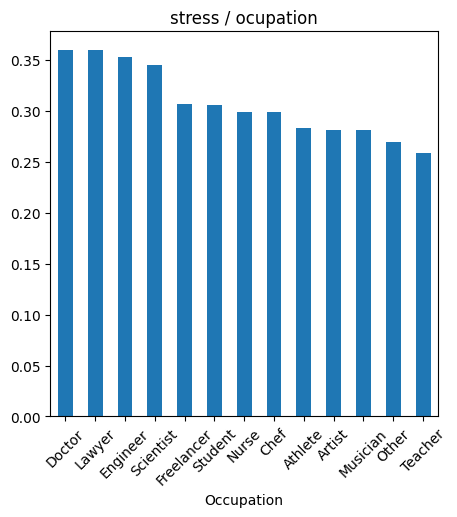

In [29]:
plt.figure(figsize=[5 , 5])
job_anxiety_rate.plot(kind='bar')
plt.title("stress / ocupation")
plt.xticks(rotation=45)

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">
گام دوم – پیش پردازش
</p>


In [30]:
x = dataset.drop(columns=["binary_anxiety" , "Anxiety Level (1-10)"])
y=dataset["binary_anxiety"]


In [31]:
numeric_features = x.select_dtypes(include=np.number).columns.tolist()
numeric_features 

['Age',
 'Sleep Hours',
 'Physical Activity (hrs/week)',
 'Caffeine Intake (mg/day)',
 'Alcohol Consumption (drinks/week)',
 'Stress Level (1-10)',
 'Heart Rate (bpm)',
 'Breathing Rate (breaths/min)',
 'Sweating Level (1-5)',
 'Therapy Sessions (per month)',
 'Diet Quality (1-10)']

In [32]:
categorical_features = x.select_dtypes(include=np.object_).columns.tolist()
categorical_features

['Gender',
 'Occupation',
 'Smoking',
 'Family History of Anxiety',
 'Dizziness',
 'Medication',
 'Recent Major Life Event']

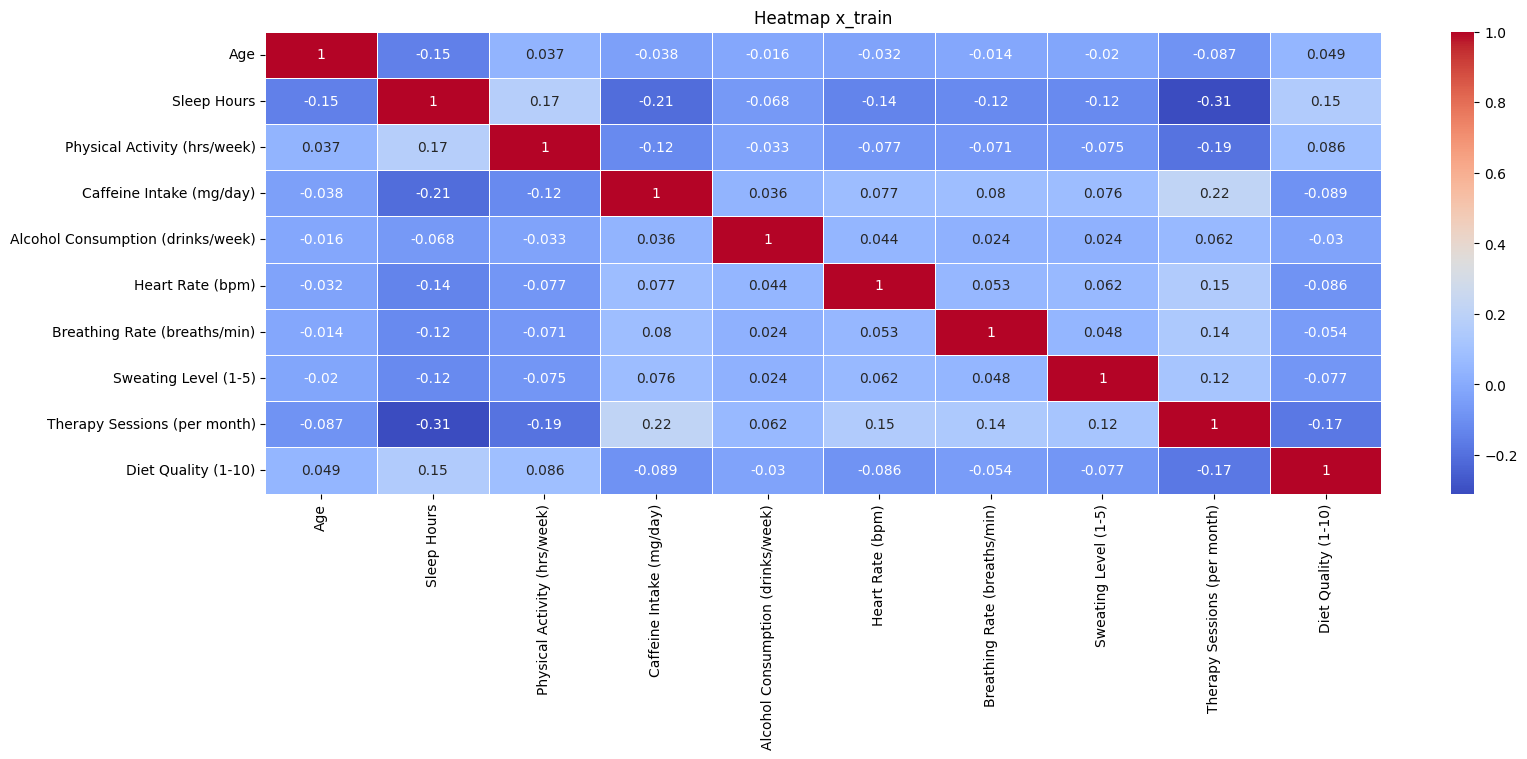

In [33]:

plt.figure(figsize=(18,6))
sns.heatmap(dataset[numeric_features].drop(columns="Stress Level (1-10)").corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap x_train")
plt.show()


<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">
تبدیل داده های عدد به استاندارد و تبدیل داده های متنی به one_hot</p>


In [34]:
num_t = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_t = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False))
])


preprocessor = ColumnTransformer(transformers=[('num_transformer',num_t, numeric_features),
                                               ('cat_transformer',cat_t, categorical_features)],
                                )

preprocessor

,transformers,"[('num_transformer', ...), ('cat_transformer', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [35]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42,
)


x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [36]:
print(f"  X_train_np: {x_train_processed.shape}")
print(f"  X_test_np: {x_test_processed.shape}")

  X_train_np: (7700, 37)
  X_test_np: (3300, 37)


<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">
PCA</p>


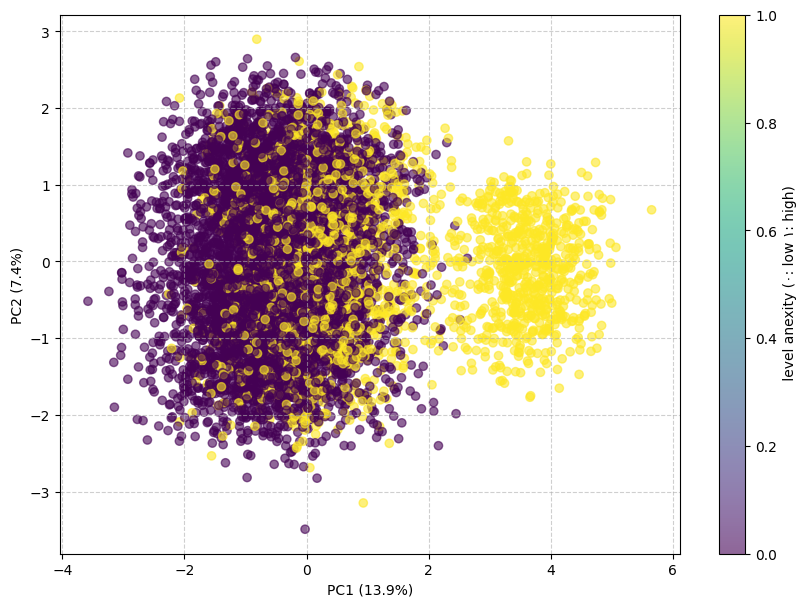

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_train_processed)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.colorbar(scatter, label=' level anexity (۰: low ۱: high)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [38]:
cat_cols_ohe = preprocessor.named_transformers_['cat_transformer']['onehot'].get_feature_names_out(categorical_features)

all_feature = numeric_features + cat_cols_ohe.tolist()
(all_feature)


['Age',
 'Sleep Hours',
 'Physical Activity (hrs/week)',
 'Caffeine Intake (mg/day)',
 'Alcohol Consumption (drinks/week)',
 'Stress Level (1-10)',
 'Heart Rate (bpm)',
 'Breathing Rate (breaths/min)',
 'Sweating Level (1-5)',
 'Therapy Sessions (per month)',
 'Diet Quality (1-10)',
 'Gender_Female',
 'Gender_Male',
 'Gender_Other',
 'Occupation_Artist',
 'Occupation_Athlete',
 'Occupation_Chef',
 'Occupation_Doctor',
 'Occupation_Engineer',
 'Occupation_Freelancer',
 'Occupation_Lawyer',
 'Occupation_Musician',
 'Occupation_Nurse',
 'Occupation_Other',
 'Occupation_Scientist',
 'Occupation_Student',
 'Occupation_Teacher',
 'Smoking_No',
 'Smoking_Yes',
 'Family History of Anxiety_No',
 'Family History of Anxiety_Yes',
 'Dizziness_No',
 'Dizziness_Yes',
 'Medication_No',
 'Medication_Yes',
 'Recent Major Life Event_No',
 'Recent Major Life Event_Yes']

In [39]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=all_feature
)

print(loadings)


                                        PC1       PC2
Age                               -0.048914  0.857795
Sleep Hours                       -0.425572 -0.451245
Physical Activity (hrs/week)      -0.288294  0.001983
Caffeine Intake (mg/day)           0.330296  0.003300
Alcohol Consumption (drinks/week)  0.101933  0.004164
Stress Level (1-10)                0.322322 -0.102250
Heart Rate (bpm)                   0.251534 -0.072049
Breathing Rate (breaths/min)       0.210419  0.054355
Sweating Level (1-5)               0.206513  0.014339
Therapy Sessions (per month)       0.491523 -0.127870
Diet Quality (1-10)               -0.279999  0.139644
Gender_Female                      0.000699  0.001789
Gender_Male                        0.001606 -0.008562
Gender_Other                      -0.002306  0.006773
Occupation_Artist                 -0.007359 -0.000259
Occupation_Athlete                -0.004948  0.001907
Occupation_Chef                   -0.001539 -0.004081
Occupation_Doctor           

-------------------------------------------------------------------

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">
گام سوم –پیاده سازی الگوریتمlogistic Regression 
</p>


In [40]:
class LogisticRegressionScratch:
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, batch_size=32):
        self.alpha = learning_rate
        self.epochs = n_iterations
        self.batch_size = batch_size 
        self.w = None
        self.b = None
        self.cost_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
        
    
    def cost_function(self, X , Y):
        m, n = X.shape
        cost_sum = 0
        eps = 1e-15
        
        z = np.dot(X, self.w) + self.b
        g = self.sigmoid(z)
        g = np.clip(g, eps, 1 - eps)
        cost = (-1 / m) * np.sum(Y * np.log(g) + (1 - Y) * np.log(1 - g))
        
        return cost

    def gradient_function(self, X , Y):
        m, n = X.shape
        z = np.dot(X, self.w) + self.b
        h = self.sigmoid(z)
        error = h - Y 
        grad_w = (1 / m) * np.dot(X.T, error)
        grad_b = (1 / m) * np.sum(error)

        return grad_b , grad_w 
        
    def fit(self, X_train, y_train):
        m, n = X_train.shape
        self.w = np.zeros(n)
        self.b = 0
        self.cost_history = []
        
        num_batches = int(m / self.batch_size) 
        
        for epoch in range(self.epochs):
            indices = np.arange(m)
            np.random.shuffle(indices)
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train[indices]

            for i in range(num_batches):
                start = i * self.batch_size
                end = min(start + self.batch_size, m)

                X_batch = X_train_shuffled[start : end]
                y_batch = y_train_shuffled[start : end]
                
                grad_b , grad_w = self.gradient_function(X_batch , y_batch)

                self.w -= self.alpha * grad_w
                self.b -= self.alpha * grad_b

            cost_value = self.cost_function(X_train, y_train)
            self.cost_history.append(cost_value) 
            
            if (epoch + 1) % 100 == 0: 
                 print(f"Epoch {epoch + 1} : Cost {cost_value:.4f}")
                 
        return self

    def predict_proba(self, X):
        z = np.dot(X, self.w) + self.b
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)



In [41]:
X_train_np = x_train_processed
y_train_np = y_train.to_numpy()

lr_scratch = LogisticRegressionScratch(learning_rate=0.01, n_iterations=1000, batch_size=64) 
lr_scratch.fit(X_train_np, y_train_np)

lr_scratch_y_pred = lr_scratch.predict(x_test_processed)
lr_scratch_y_prba = lr_scratch.predict_proba(x_test_processed)


Epoch 100 : Cost 0.3478
Epoch 200 : Cost 0.3477
Epoch 300 : Cost 0.3477
Epoch 400 : Cost 0.3477
Epoch 500 : Cost 0.3477
Epoch 600 : Cost 0.3477
Epoch 700 : Cost 0.3477
Epoch 800 : Cost 0.3477
Epoch 900 : Cost 0.3477
Epoch 1000 : Cost 0.3477


<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">
گام چهارم–نمودار همگرایی و تحلیل نرخ یادگیری</p>


Epoch 100 : Cost 0.3480
Epoch 200 : Cost 0.3479
Epoch 300 : Cost 0.3483
Epoch 400 : Cost 0.3483
Epoch 500 : Cost 0.3493
Epoch 600 : Cost 0.3488
Epoch 700 : Cost 0.3486
Epoch 800 : Cost 0.3482
Epoch 900 : Cost 0.3493
Epoch 1000 : Cost 0.3481
Epoch 100 : Cost 0.3477
Epoch 200 : Cost 0.3477
Epoch 300 : Cost 0.3477
Epoch 400 : Cost 0.3477
Epoch 500 : Cost 0.3477
Epoch 600 : Cost 0.3477
Epoch 700 : Cost 0.3477
Epoch 800 : Cost 0.3477
Epoch 900 : Cost 0.3477
Epoch 1000 : Cost 0.3477
Epoch 100 : Cost 0.3512
Epoch 200 : Cost 0.3482
Epoch 300 : Cost 0.3479
Epoch 400 : Cost 0.3478
Epoch 500 : Cost 0.3478
Epoch 600 : Cost 0.3477
Epoch 700 : Cost 0.3477
Epoch 800 : Cost 0.3477
Epoch 900 : Cost 0.3477
Epoch 1000 : Cost 0.3477


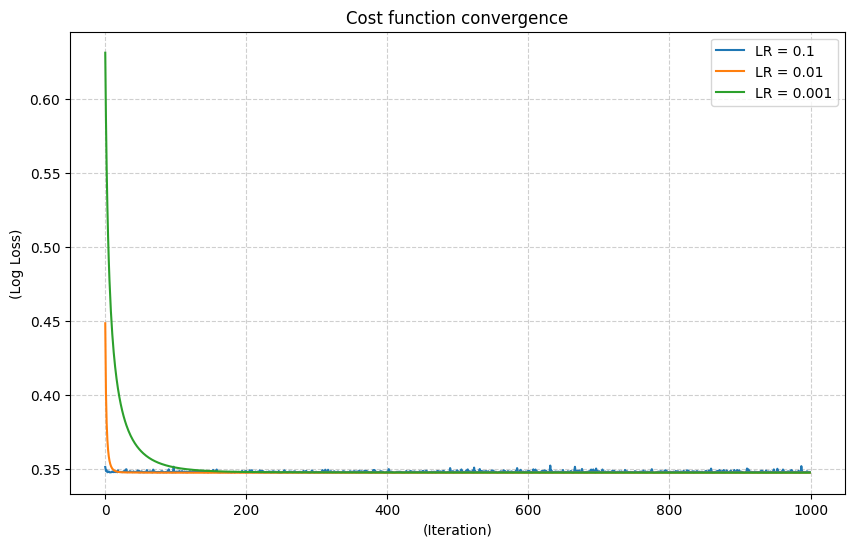

In [42]:
learning_rates = [0.1, 0.01, 0.001]
n_iters = 1000 
models_lr = {}

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    model = LogisticRegressionScratch(learning_rate=lr, n_iterations=n_iters) 
    model.fit(X_train_np, y_train.to_numpy())
    models_lr[lr] = model
    model.predict
    
    plt.plot(model.cost_history, label=f'LR = {lr}')

plt.xlabel('(Iteration)')
plt.ylabel('(Log Loss)')
plt.title('Cost function convergence')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [43]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_proba),
        'Log Loss': log_loss(y_true, y_proba),
        'Conf Matrix': confusion_matrix(y_true, y_pred).ravel() 
    }
    return results

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">
گام پنجم–الگوریتمNaïve Bayes</p>



In [44]:
lr_sklearn = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)
lr_sklearn.fit(x_train_processed, y_train)
y_pred_lr = lr_sklearn.predict(x_test_processed)
y_proba_lr = lr_sklearn.predict_proba(x_test_processed)[:, 1]

nb_model = GaussianNB()
nb_model.fit(x_train_processed, y_train)
y_pred_nb = nb_model.predict(x_test_processed)
y_proba_nb = nb_model.predict_proba(x_test_processed)[:, 1]

lr_results_scratch = evaluate_model(y_test, lr_scratch_y_pred, lr_scratch_y_prba, 'LR scratch')
nb_results = evaluate_model(y_test, y_pred_nb, y_proba_nb, 'NB')
lr_results = evaluate_model(y_test, y_pred_lr, y_proba_lr, 'LR')

results_df = pd.DataFrame([nb_results, lr_results , lr_results_scratch])

# TN, FP, FN, TP 
print(results_df.set_index('Model'))
print("-" * 150)


            Accuracy  Precision    Recall  F1-Score       AUC  Log Loss  \
Model                                                                     
NB          0.806061   0.744656  0.596008  0.662091  0.880871  0.477407   
LR          0.842121   0.795987  0.678707  0.732683  0.913530  0.337065   
LR scratch  0.842121   0.795987  0.678707  0.732683  0.913519  0.337047   

                      Conf Matrix  
Model                              
NB          [2033, 215, 425, 627]  
LR          [2065, 183, 338, 714]  
LR scratch  [2065, 183, 338, 714]  
------------------------------------------------------------------------------------------------------------------------------------------------------


<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">
گام ششم–ترسیم مرز تصمیم</p>


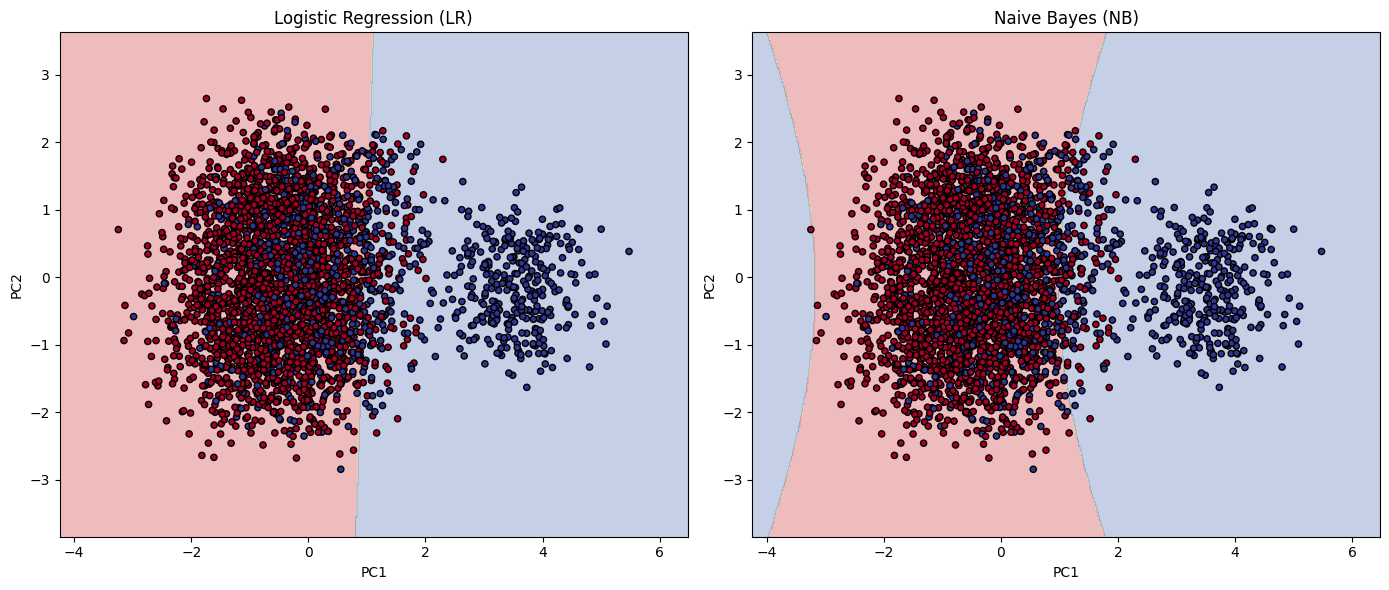

In [45]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(x_train_processed) 
X_test_2d = pca.transform(x_test_processed)


lr_2d = LogisticRegression(solver='lbfgs', random_state=42).fit(X_train_2d, y_train)
nb_2d = GaussianNB().fit(X_train_2d, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

h = 0.02
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

y_test_np = y_test.to_numpy() 

# Logistic Regression
Z_lr = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = Z_lr.reshape(xx.shape)
axes[0].contourf(xx, yy, Z_lr, alpha=0.3, cmap=plt.cm.RdYlBu)
axes[0].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_np, cmap=plt.cm.RdYlBu, edgecolors='k', marker='o', s=20)
axes[0].set_title('Logistic Regression (LR)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Naive Bayes
Z_nb = nb_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_nb = Z_nb.reshape(xx.shape)
axes[1].contourf(xx, yy, Z_nb, alpha=0.3, cmap=plt.cm.RdYlBu)
axes[1].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_np, cmap=plt.cm.RdYlBu, edgecolors='k', marker='o', s=20)
axes[1].set_title('Naive Bayes (NB)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

--------------------------------------